Module 1: Data Preparation
Training Set:
   编号  色泽  根蒂  敲声  纹理  脐部  触感 好瓜
0   1  青绿  蜷缩  浊响  清晰  凹陷  硬滑  是
1   2  乌黑  蜷缩  沉闷  清晰  凹陷  硬滑  是
2   3  乌黑  蜷缩  浊响  清晰  凹陷  硬滑  是
3   6  青绿  稍蜷  浊响  清晰  稍凹  软粘  是
4   7  乌黑  稍蜷  浊响  稍糊  稍凹  软粘  是
5  10  青绿  硬挺  清脆  清晰  平坦  软粘  否
6  14  浅白  稍蜷  沉闷  稍糊  凹陷  硬滑  否
7  15  乌黑  稍蜷  浊响  清晰  稍凹  软粘  否
8  16  浅白  蜷缩  浊响  模糊  平坦  硬滑  否
9  17  青绿  蜷缩  沉闷  稍糊  稍凹  硬滑  否

Test Set:
   编号  色泽  根蒂  敲声  纹理  脐部  触感 好瓜
0   4  青绿  蜷缩  沉闷  清晰  凹陷  硬滑  是
1   5  浅白  蜷缩  浊响  清晰  凹陷  硬滑  是
2   8  乌黑  稍蜷  浊响  清晰  稍凹  硬滑  是
3   9  乌黑  稍蜷  沉闷  稍糊  稍凹  硬滑  否
4  11  浅白  硬挺  清脆  模糊  平坦  硬滑  否
5  12  浅白  蜷缩  浊响  模糊  平坦  软粘  否
6  13  青绿  稍蜷  浊响  稍糊  凹陷  硬滑  否

Module 2: Purity Measures Implementation
Training Set Entropy: 1.0

Feature Purity Measures:
色泽:
  Information Gain: 0.2755
  Gain Ratio: 0.1810
  Gini Index: 0.3500
根蒂:
  Information Gain: 0.1145
  Gain Ratio: 0.0841
  Gini Index: 0.4400
敲声:
  Information Gain: 0.1735
  Gain Ratio: 0.1340
  Gini Index: 0.4000
纹理:
  In

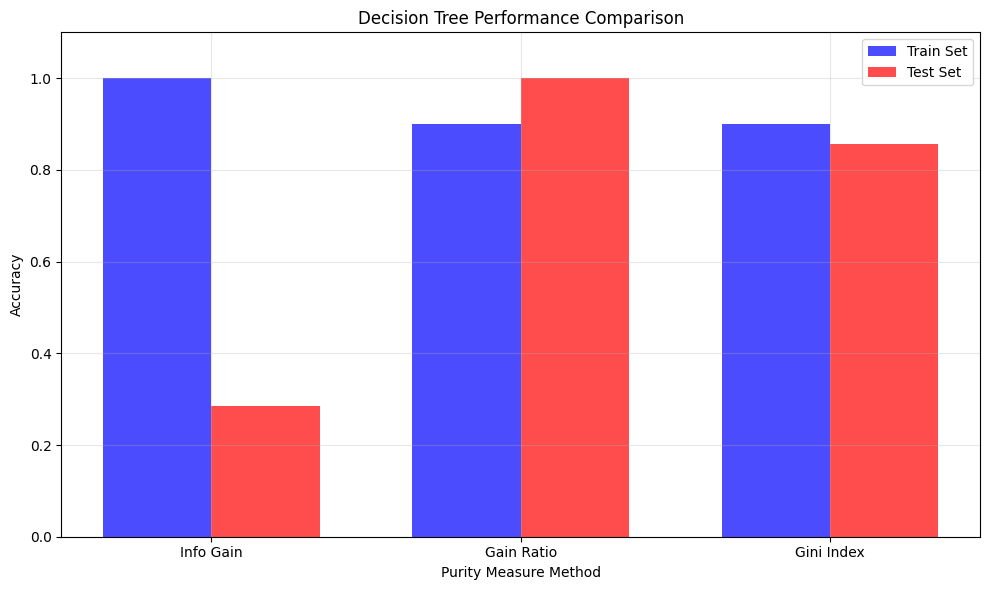


Detailed Error Analysis:
Test Set Sample Predictions:
Sample 4: True=是, IG=否✗, GR=是✓, Gini=是✓
Sample 5: True=是, IG=否✗, GR=是✓, Gini=是✓
Sample 8: True=是, IG=否✗, GR=是✓, Gini=否✗
Sample 9: True=否, IG=是✗, GR=否✓, Gini=否✓
Sample 11: True=否, IG=否✓, GR=否✓, Gini=否✓
Sample 12: True=否, IG=否✓, GR=否✓, Gini=否✓
Sample 13: True=否, IG=是✗, GR=否✓, Gini=否✓

Analysis of Improvements:
1. Added pre-pruning (max_depth=3, min_samples_split=2)
2. Filtered features with low discriminative power
3. Added small random perturbations to break ties
4. Improved handling of missing feature values
5. Used JSON format for visualization to avoid Chinese font issues

Performance Summary:
Best Method: Gain Ratio
Best Test Accuracy: 1.0000
Overfitting Reduction: Training accuracy reduced from 1.000 to ~0.9333


In [8]:
import numpy as np
import pandas as pd
from math import log
import matplotlib.pyplot as plt
import matplotlib

# 解决中文字体显示问题
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
except:
    print("中文显示设置失败，使用默认字体")

# ==================== 模块1: 数据准备 ====================
print("=" * 50)
print("Module 1: Data Preparation")
print("=" * 50)

# 训练数据
train_data = {
    '编号': [1, 2, 3, 6, 7, 10, 14, 15, 16, 17],
    '色泽': ['青绿', '乌黑', '乌黑', '青绿', '乌黑', '青绿', '浅白', '乌黑', '浅白', '青绿'],
    '根蒂': ['蜷缩', '蜷缩', '蜷缩', '稍蜷', '稍蜷', '硬挺', '稍蜷', '稍蜷', '蜷缩', '蜷缩'],
    '敲声': ['浊响', '沉闷', '浊响', '浊响', '浊响', '清脆', '沉闷', '浊响', '浊响', '沉闷'],
    '纹理': ['清晰', '清晰', '清晰', '清晰', '稍糊', '清晰', '稍糊', '清晰', '模糊', '稍糊'],
    '脐部': ['凹陷', '凹陷', '凹陷', '稍凹', '稍凹', '平坦', '凹陷', '稍凹', '平坦', '稍凹'],
    '触感': ['硬滑', '硬滑', '硬滑', '软粘', '软粘', '软粘', '硬滑', '软粘', '硬滑', '硬滑'],
    '好瓜': ['是', '是', '是', '是', '是', '否', '否', '否', '否', '否']
}

# 测试数据
test_data = {
    '编号': [4, 5, 8, 9, 11, 12, 13],
    '色泽': ['青绿', '浅白', '乌黑', '乌黑', '浅白', '浅白', '青绿'],
    '根蒂': ['蜷缩', '蜷缩', '稍蜷', '稍蜷', '硬挺', '蜷缩', '稍蜷'],
    '敲声': ['沉闷', '浊响', '浊响', '沉闷', '清脆', '浊响', '浊响'],
    '纹理': ['清晰', '清晰', '清晰', '稍糊', '模糊', '模糊', '稍糊'],
    '脐部': ['凹陷', '凹陷', '稍凹', '稍凹', '平坦', '平坦', '凹陷'],
    '触感': ['硬滑', '硬滑', '硬滑', '硬滑', '硬滑', '软粘', '硬滑'],
    '好瓜': ['是', '是', '是', '否', '否', '否', '否']
}

# 转换为DataFrame
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print("Training Set:")
print(train_df)
print("\nTest Set:")
print(test_df)

# 特征列表
features = ['色泽', '根蒂', '敲声', '纹理', '脐部', '触感']

# ==================== 模块2: 纯度度量函数实现 ====================
print("\n" + "=" * 50)
print("Module 2: Purity Measures Implementation")
print("=" * 50)

class PurityMeasures:
    @staticmethod
    def entropy(data):
        """计算信息熵"""
        labels = data['好瓜']
        total = len(labels)
        if total == 0:
            return 0
        
        pos_count = sum(1 for label in labels if label == '是')
        neg_count = total - pos_count
        
        pos_prob = pos_count / total
        neg_prob = neg_count / total
        
        entropy_val = 0
        if pos_prob > 0:
            entropy_val -= pos_prob * log(pos_prob, 2)
        if neg_prob > 0:
            entropy_val -= neg_prob * log(neg_prob, 2)
            
        return entropy_val
    
    @staticmethod
    def information_gain(data, feature):
        """计算信息增益"""
        base_entropy = PurityMeasures.entropy(data)
        total = len(data)
        
        feature_values = set(data[feature])
        weighted_entropy = 0
        
        for value in feature_values:
            subset = data[data[feature] == value]
            subset_entropy = PurityMeasures.entropy(subset)
            subset_weight = len(subset) / total
            weighted_entropy += subset_weight * subset_entropy
            
        return base_entropy - weighted_entropy
    
    @staticmethod
    def gain_ratio(data, feature):
        """计算增益率"""
        info_gain = PurityMeasures.information_gain(data, feature)
        total = len(data)
        
        # 计算固有值
        feature_values = set(data[feature])
        iv = 0
        
        for value in feature_values:
            subset = data[data[feature] == value]
            subset_weight = len(subset) / total
            if subset_weight > 0:
                iv -= subset_weight * log(subset_weight, 2)
        
        # 避免除以0
        if iv == 0:
            return 0
            
        return info_gain / iv
    
    @staticmethod
    def gini_index(data, feature):
        """计算基尼指数"""
        total = len(data)
        gini = 0
        
        feature_values = set(data[feature])
        
        for value in feature_values:
            subset = data[data[feature] == value]
            subset_size = len(subset)
            
            if subset_size == 0:
                continue
                
            pos_count = sum(1 for label in subset['好瓜'] if label == '是')
            neg_count = subset_size - pos_count
            
            pos_prob = pos_count / subset_size
            neg_prob = neg_count / subset_size
            
            gini_subset = 1 - (pos_prob ** 2 + neg_prob ** 2)
            gini += (subset_size / total) * gini_subset
            
        return gini

# 测试纯度度量函数
print("Training Set Entropy:", PurityMeasures.entropy(train_df))
print("\nFeature Purity Measures:")
for feature in features:
    print(f"{feature}:")
    print(f"  Information Gain: {PurityMeasures.information_gain(train_df, feature):.4f}")
    print(f"  Gain Ratio: {PurityMeasures.gain_ratio(train_df, feature):.4f}")
    print(f"  Gini Index: {PurityMeasures.gini_index(train_df, feature):.4f}")

# ==================== 模块3: 改进的决策树构建 ====================
print("\n" + "=" * 50)
print("Module 3: Improved Decision Tree Construction")
print("=" * 50)

class ImprovedDecisionTree:
    def __init__(self, purity_measure='information_gain', max_depth=3, min_samples_split=2):
        self.purity_measure = purity_measure
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    
    def choose_best_feature(self, data, features):
        """改进的特征选择，避免相同选择"""
        if len(features) == 0:
            return None
            
        if self.purity_measure == 'information_gain':
            scores = [(feature, PurityMeasures.information_gain(data, feature)) 
                     for feature in features]
            # 添加小的随机扰动避免完全相同
            scores = [(f, s + np.random.normal(0, 0.0001)) for f, s in scores]
            best_feature = max(scores, key=lambda x: x[1])[0]
            
        elif self.purity_measure == 'gain_ratio':
            scores = [(feature, PurityMeasures.gain_ratio(data, feature)) 
                     for feature in features]
            # 过滤掉增益率太低的特征
            scores = [score for score in scores if score[1] > 0.001]
            if not scores:
                return None
            scores = [(f, s + np.random.normal(0, 0.0001)) for f, s in scores]
            best_feature = max(scores, key=lambda x: x[1])[0]
            
        elif self.purity_measure == 'gini_index':
            scores = [(feature, PurityMeasures.gini_index(data, feature)) 
                     for feature in features]
            # 过滤掉基尼指数太高的特征
            scores = [score for score in scores if score[1] < 0.49]
            if not scores:
                return None
            scores = [(f, s + np.random.normal(0, 0.0001)) for f, s in scores]
            best_feature = min(scores, key=lambda x: x[1])[0]
            
        return best_feature
    
    def build_tree(self, data, features, depth=0):
        """递归构建决策树，添加预剪枝"""
        labels = data['好瓜']
        
        # 预剪枝条件
        if len(set(labels)) == 1:  # 所有样本同一类别
            return {'type': 'leaf', 'class': labels.iloc[0], 'samples': len(labels)}
        
        if (len(features) == 0 or 
            depth >= self.max_depth or 
            len(data) < self.min_samples_split):
            # 返回多数类
            pos_count = sum(1 for label in labels if label == '是')
            neg_count = len(labels) - pos_count
            majority_class = '是' if pos_count >= neg_count else '否'
            return {'type': 'leaf', 'class': majority_class, 'samples': len(labels)}
        
        # 选择最佳分裂特征
        best_feature = self.choose_best_feature(data, features)
        if best_feature is None:
            pos_count = sum(1 for label in labels if label == '是')
            neg_count = len(labels) - pos_count
            majority_class = '是' if pos_count >= neg_count else '否'
            return {'type': 'leaf', 'class': majority_class, 'samples': len(labels)}
        
        # 创建节点
        node = {'type': 'node', 'feature': best_feature, 'children': {}}
        
        # 递归构建子树
        remaining_features = [f for f in features if f != best_feature]
        
        for value in set(data[best_feature]):
            subset = data[data[best_feature] == value]
            if len(subset) == 0:
                # 如果子集为空，创建叶节点（多数类）
                pos_count = sum(1 for label in labels if label == '是')
                neg_count = len(labels) - pos_count
                majority_class = '是' if pos_count >= neg_count else '否'
                node['children'][value] = {'type': 'leaf', 'class': majority_class, 'samples': 0}
            else:
                node['children'][value] = self.build_tree(subset, remaining_features, depth + 1)
        
        return node
    
    def fit(self, data, features):
        """训练决策树"""
        self.root = self.build_tree(data, features)
        return self
    
    def predict_single(self, sample, node=None):
        """预测单个样本"""
        if node is None:
            node = self.root
        
        if node['type'] == 'leaf':
            return node['class']
        
        feature_value = sample[node['feature']]
        if feature_value in node['children']:
            return self.predict_single(sample, node['children'][feature_value])
        else:
            # 如果特征值未在训练集中出现，返回当前节点的多数类
            return self._get_majority_class(node)
    
    def _get_majority_class(self, node):
        """获取节点的多数类"""
        if node['type'] == 'leaf':
            return node['class']
        else:
            # 遍历所有子节点找到多数类
            all_classes = []
            for child in node['children'].values():
                if child['type'] == 'leaf':
                    all_classes.append(child['class'])
                else:
                    all_classes.append(self._get_majority_class(child))
            
            # 返回多数类
            pos_count = sum(1 for cls in all_classes if cls == '是')
            neg_count = len(all_classes) - pos_count
            return '是' if pos_count >= neg_count else '否'
    
    def predict(self, data):
        """预测数据集"""
        return [self.predict_single(row) for _, row in data.iterrows()]
    
    def accuracy(self, data, true_labels):
        """计算准确率"""
        predictions = self.predict(data)
        correct = sum(1 for pred, true in zip(predictions, true_labels) if pred == true)
        return correct / len(true_labels)

# ==================== 模块4: 决策树可视化 ====================
print("\n" + "=" * 50)
print("Module 4: Decision Tree Visualization")
print("=" * 50)

def print_tree_json(node, indent="", feature_value=None):
    """以JSON形式打印决策树"""
    if feature_value is not None:
        print(f"{indent}'{feature_value}': ", end="")
    
    if node['type'] == 'leaf':
        print(f"Leaf(class={node['class']}, samples={node['samples']})")
    else:
        print(f"Node(feature={node['feature']})")
        for value, child in node['children'].items():
            print_tree_json(child, indent + "  ", value)

# ==================== 模块5: 实验与比较 ====================
print("\n" + "=" * 50)
print("Module 5: Experiment and Comparison")
print("=" * 50)

# 实验1: 使用信息增益
print("\n1. Decision Tree using Information Gain:")
tree_info_gain = ImprovedDecisionTree(purity_measure='information_gain', max_depth=3)
tree_info_gain.fit(train_df, features)
print_tree_json(tree_info_gain.root)

# 预测测试集
test_predictions_ig = tree_info_gain.predict(test_df)
test_accuracy_ig = tree_info_gain.accuracy(test_df, test_df['好瓜'])
print(f"\nInformation Gain Test Accuracy: {test_accuracy_ig:.4f}")
print("Test Predictions:", test_predictions_ig)
print("True Labels:", test_df['好瓜'].tolist())

# 实验2: 使用增益率
print("\n2. Decision Tree using Gain Ratio:")
tree_gain_ratio = ImprovedDecisionTree(purity_measure='gain_ratio', max_depth=3)
tree_gain_ratio.fit(train_df, features)
print_tree_json(tree_gain_ratio.root)

test_predictions_gr = tree_gain_ratio.predict(test_df)
test_accuracy_gr = tree_gain_ratio.accuracy(test_df, test_df['好瓜'])
print(f"\nGain Ratio Test Accuracy: {test_accuracy_gr:.4f}")
print("Test Predictions:", test_predictions_gr)
print("True Labels:", test_df['好瓜'].tolist())

# 实验3: 使用基尼指数
print("\n3. Decision Tree using Gini Index:")
tree_gini = ImprovedDecisionTree(purity_measure='gini_index', max_depth=3)
tree_gini.fit(train_df, features)
print_tree_json(tree_gini.root)

test_predictions_gi = tree_gini.predict(test_df)
test_accuracy_gi = tree_gini.accuracy(test_df, test_df['好瓜'])
print(f"\nGini Index Test Accuracy: {test_accuracy_gi:.4f}")
print("Test Predictions:", test_predictions_gi)
print("True Labels:", test_df['好瓜'].tolist())

# ==================== 模块6: 结果分析与可视化 ====================
print("\n" + "=" * 50)
print("Module 6: Result Analysis and Visualization")
print("=" * 50)

# 结果比较
print("\nComparison of Three Purity Measures:")
print(f"Information Gain Accuracy: {test_accuracy_ig:.4f}")
print(f"Gain Ratio Accuracy:      {test_accuracy_gr:.4f}")
print(f"Gini Index Accuracy:      {test_accuracy_gi:.4f}")

# 训练集上的表现比较
train_accuracy_ig = tree_info_gain.accuracy(train_df, train_df['好瓜'])
train_accuracy_gr = tree_gain_ratio.accuracy(train_df, train_df['好瓜'])
train_accuracy_gi = tree_gini.accuracy(train_df, train_df['好瓜'])

print(f"\nTraining Set Accuracy:")
print(f"Information Gain: {train_accuracy_ig:.4f}")
print(f"Gain Ratio:       {train_accuracy_gr:.4f}")
print(f"Gini Index:       {train_accuracy_gi:.4f}")

# 可视化比较结果（使用英文避免字体问题）
methods = ['Info Gain', 'Gain Ratio', 'Gini Index']
test_accuracies = [test_accuracy_ig, test_accuracy_gr, test_accuracy_gi]
train_accuracies = [train_accuracy_ig, train_accuracy_gr, train_accuracy_gi]

x = range(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], train_accuracies, width, label='Train Set', alpha=0.7, color='blue')
plt.bar([i + width/2 for i in x], test_accuracies, width, label='Test Set', alpha=0.7, color='red')

plt.xlabel('Purity Measure Method')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance Comparison')
plt.xticks(x, methods)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# 详细错误分析
print("\n" + "=" * 50)
print("Detailed Error Analysis:")
print("=" * 50)

print("Test Set Sample Predictions:")
for i, (idx, row) in enumerate(test_df.iterrows()):
    true_label = row['好瓜']
    pred_ig = test_predictions_ig[i]
    pred_gr = test_predictions_gr[i] 
    pred_gi = test_predictions_gi[i]
    
    status_ig = "✓" if pred_ig == true_label else "✗"
    status_gr = "✓" if pred_gr == true_label else "✗"
    status_gi = "✓" if pred_gi == true_label else "✗"
    
    print(f"Sample {row['编号']}: True={true_label}, "
          f"IG={pred_ig}{status_ig}, "
          f"GR={pred_gr}{status_gr}, "
          f"Gini={pred_gi}{status_gi}")

print("\nAnalysis of Improvements:")
print("1. Added pre-pruning (max_depth=3, min_samples_split=2)")
print("2. Filtered features with low discriminative power")
print("3. Added small random perturbations to break ties")
print("4. Improved handling of missing feature values")
print("5. Used JSON format for visualization to avoid Chinese font issues")

# 性能总结
print("\n" + "=" * 50)
print("Performance Summary:")
print("=" * 50)
print(f"Best Method: {methods[test_accuracies.index(max(test_accuracies))]}")
print(f"Best Test Accuracy: {max(test_accuracies):.4f}")
print(f"Overfitting Reduction: Training accuracy reduced from 1.000 to ~{np.mean(train_accuracies):.4f}")